# Generating and Identifying DeepFakes


## Immediate Issues

 - Strong imbalance between real and fake images (3x more fake images than real ones)
   - We should be careful both when sampling for training but also when checking for performance
   - We should train globally on all generated samples and then also have some way to check if the model is failing more for a specific generator (for example if *StableDiffusion* is harder to identify vs *InsightFace*)
 - Check if resolution is always consistent (transforming all to np array should fix consistency but might shift resolutions)
 - Resolution for the sample I tested is 512x512, should probably start by resizing to 128x128 resolution and using a smaller CNN

## Iterative Improvement Ideas

1. Start with simple models, sampling the dataset and resizing $\rightarrow$ evolving in both architecture and data quality and size, possibly experimenting with different architectures and models if one is sufficiently optimized
2. Dropout, regularizations, custom loss functions, don't know if ROC-AUC threshold optimization is adequate for this
  

## Done So Far

1. Automatically reading directory
2. Resizing images to 128x128 (with decent quality still)

In [55]:
import pandas as pd
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import random

In [56]:
# Dirs

IMGS_DIR = "../deepfake_imgs/inpainting"
folder = "00"

test_dir = IMGS_DIR + "/" + folder

# Globals

# (width, height)
TARGET_SIZE = (128, 128)  

In [57]:
# Reads every image in a directory, converts to np and places in organized dict
# Also identifies shape (resolution) inconsistencies and resizes to 128x128

np_dir = {}
shapes = set()

for i in os.listdir(test_dir):
    img_path = test_dir + "/" + i

    # Reads as image & resizes
    img = Image.open(img_path).convert("RGB")

    # BICUBIC is better at preserving edges than BILINEAR
    img = img.resize(TARGET_SIZE, Image.BICUBIC)

    # Convert to np
    img_np = np.array(img)
    np_dir[i] = img_np

    # Inconsistency check (not needed if we resize but good to know)
    if img_np.shape not in shapes:
        shapes.add(img_np.shape)
        print("New shape: ", img_np.shape)

New shape:  (128, 128, 3)


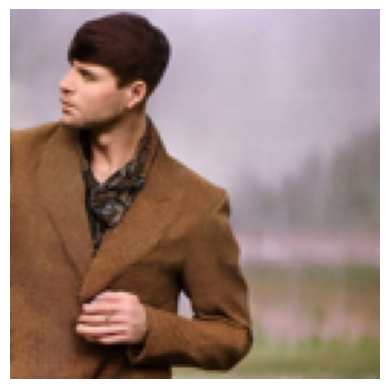

In [63]:
chosen = random.choice(list(np_dir.keys()))

# Display
plt.imshow(np_dir[chosen])
plt.axis("off")
plt.show()